# Candidate outliers and representative samples

This notebook identifies:

1. **Cell-level unusual laboratory results** for the already-selected columns.
2. **Sample-level candidates for review or retesting**, using agreement between robust univariate and multivariate methods.
3. **Representative samples** near the center, mean, lower quartile, and upper quartile of the observed data.

The methods produce **review candidates, not automatic exclusions**. Natural environmental extremes can be valid, and reported zeros may represent non-detects. The main thresholds and selected columns remain editable in the parameter cells.

# Setup

## Imports

In [43]:
from pathlib import Path
from dataclasses import dataclass
import os
import sys
import warnings

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

import hatfield_funcs as hf

# Project root = one level up from notebooks, possibly more from here.
project_root = Path("../..").resolve()
sys.path.insert(0, str(project_root / "src"))

from biofilm_spectra.processing.spectral_matrix import to_spectral_matrix
from biofilm_spectra.processing.micasense import *
from my_extra_to_hatfield_funcs.io_funcs import *

In [44]:
plt.style.use("default")
%config InlineBackend.figure_format = "retina"
sns.set_context("notebook")

In [45]:
CONTAINER_NAME = "wesa-fup-restricted-027817p"

if os.getenv("GA_STORAGE_ACCOUNT_NAME") is not None:
    # Used with Azure cloud storage (GeoAnalytics).
    hf.config.configure_azure()
    hf.config.configure_data_root_path(CONTAINER_NAME)
else:
    raise Exception(
        "This notebook is configured to run in the cloud. "
        "Please set up your Azure storage account and container name."
    )

## Parameters

In [46]:
SITES = ["brunswick", "westham"]
SITE_COLORS = {
    "brunswick": "#0455FE",
    "westham": "#56E00A",
}
SITE_LABELS = {
    "brunswick": "Impact Area",
    "westham": "Westham Control Area",
}
SITE_SHORTLABELS = {
    "brunswick": "IA",
    "westham": "WI",
}

PIGMENT_LIST = [
    "Peri", "Chlc2", "Fuco", "Ddx", "Allo", "Myxo", "Lut", "Zea",
    "Cant", "Chlb", "Chl_allo1", "Chl_allo2", "Chla", "DVCh-a",
    "Echi", "Phtb", "Phta", "Acar", "Beta",
]

FA_LIST = [
    "C6", "C8", "C10", "C11", "C12", "C13", "C14:0", "C14:1",
    "C15", "C15:1", "C16", "C16:1", "C17:0", "C17:1", "C18:0",
    "C18:1N9T", "C18:1N9C", "C18:2N6T", "C18:2N6C", "C20:0",
    "C18:3N6", "C20:1N9", "C18:3N3", "C21:0", "C20:2", "C22:0",
    "C20:3N6", "C22:1N9", "C20:3N3", "C23:0", "C20:4N6",
    "C22:2", "C24:0", "C20:5N3", "C24:1N9", "C22:6N3",
]

NORMALIZING_CHLA_COLUMN = "Chla + allomers"

In [47]:
# Input paths
path_to_combined_dataset = Path("data/processed/full_dataset_combined_grouped.csv")

# Output paths
path_output_dir = Path("./outputs/lab_data")
path_output_dir.mkdir(parents=True, exist_ok=True)

# Read data

In [48]:
df_combined_grouped = read_df_from_csv(
    path_to_combined_dataset,
    index_col=[0, 1, 2, 3],
    header=[0, 1, 2],
)

# Retain only regular samples ("R").
df_combined_grouped_R = df_combined_grouped.xs("R", level="sample_type")
df_combined_R = df_combined_grouped_R.copy()
df_combined_R.columns = df_combined_grouped_R.columns.get_level_values(2)

print("Rows:", len(df_combined_R))
print("Columns:", df_combined_R.shape[1])
display(df_combined_R.head())

Rows: 120
Columns: 246


Sample Total Dry Mass (g)  \
site      station_id round                              
brunswick B1         1                     124.920787   
                     2                     102.318373   
          B10        1                     113.372704   
                     2                     135.840106   
          B11        1                      68.488373   

                            Extraction Dry Mass (mg)  Area Sampled (m2)  \
site      station_id round                                                
brunswick B1         1                         554.2              0.082   
                     2                         512.4              0.082   
          B10        1                         460.8              0.082   
                     2                         582.7              0.082   
          B11        1                         480.4              0.082   

                            /g to /m2 Conversion Factor (g/m2)  Moisture (%)  \
site      station_id round                                                     
brunswick B1         1                             1523.424232     55.812630   
                     2                             1247.785032     46.904693   
          B10        1                             1382.593955     53.288243   
                     2                             1656.586662     45.619801   
          B11        1                              835.224056     60.344183   

                            Percent Sand (%)  Percent Silt (%)  \
site      station_id round                                       
brunswick B1         1             91.182365          7.815631   
                     2             73.170732         26.829268   
          B10        1             73.684211         25.263158   
                     2             86.597938         11.340206   
          B11        1             71.232877         27.397260   

                            Percent Clay (%) Sample Date  \
site      station_id round                                 
brunswick B1         1              1.002004  2026-05-03   
                     2              0.000000  2026-05-16   
          B10        1              1.052632  2026-05-01   
                     2              2.061856  2026-05-17   
          B11        1              1.369863  2026-05-01   

                            Time of Emergence (decimal)  ...  B05_650nm  \
site      station_id round                               ...              
brunswick B1         1                         8.800000  ...   0.083512   
                     2                         7.493590  ...   0.110762   
          B10        1                         8.253333  ...   0.097695   
                     2                         8.201191  ...   0.108726   
          B11        1                         9.463333  ...   0.083154   

                            B06_668nm  B07_705nm  B08_717nm  B09_740nm  \
site      station_id round                                               
brunswick B1         1       0.075327   0.091339   0.093436   0.095960   
                     2       0.099458   0.121518   0.124403   0.126939   
          B10        1       0.082605   0.111692   0.115371   0.118709   
                     2       0.094504   0.121075   0.124400   0.127022   
          B11        1       0.074510   0.091615   0.094074   0.096963   

                            B10_842nm  NDVI740_mean  NDVI842_mean  NDCI3_mean  \
site      station_id round                                                      
brunswick B1         1       0.102775      0.120326      0.154022    0.066917   
                     2       0.132580      0.122321      0.143667    0.070355   
          B10        1       0.124086      0.179997      0.201283    0.107470   
                     2       0.132222      0.147256      0.166821    0.088908   
          B11        1       0.103180      0.131063      0.161518    0.071969   

                            NDCI2_mean  
sit

## Select the columns to assess

In [49]:
# lab_unit_subgroup = "Lab Concentrations (/g)"  # or "Surface Densities (/m2)"
# lab_main_unit = 'mg/g'

lab_unit_subgroup = "Surface Densities (/m2)"
lab_main_unit = 'mg/m2'


# Edit this block in the future if a different set of variables is required.
columns_to_test_outliers = (
    [
        "Sample Total Dry Mass (g)",
        "Moisture (%)",
        "Percent Sand (%)",
    ]
    # + list(
    #     df_combined_grouped_R.xs(
    #         ("Pigments", lab_unit_subgroup),
    #         level=(0, 1),
    #         axis=1,
    #     ).columns
    # )
    + [
        f'Chla ({lab_main_unit})',
        f"Chl_allo1 ({lab_main_unit})",
        f"Chl_allo2 ({lab_main_unit})",
        f'DVCh-a ({lab_main_unit})',
        f'Phta ({lab_main_unit})',
        # f'Chla + allomers ({lab_main_unit})',
        # f'Chla + allomers + Phta ({lab_main_unit})',
        # f'Total Chla ({lab_main_unit})',
        # 'Chla : Phta',
    ]
    # + list(
    #     df_combined_grouped_R.xs(
    #         ("Fatty Acids", lab_unit_subgroup),
    #         level=(0, 1),
    #         axis=1,
    #     ).columns
    # )
    + [
        # f'Total FA ({lab_main_unit})',
        f'Total SFA ({lab_main_unit})',
        f'Total MUFA ({lab_main_unit})',
        f'Total PUFA ({lab_main_unit})',
    ]
    + list(
        df_combined_grouped_R.xs(
            ("Nutritional", lab_unit_subgroup),
            level=(0, 1),
            axis=1,
        ).columns
    )
)

# Preserve order while removing accidental duplicates.
columns_to_test_outliers = list(dict.fromkeys(columns_to_test_outliers))

df_to_test_outliers = (
    df_combined_R.loc[:, columns_to_test_outliers]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

print(f"Testing {len(columns_to_test_outliers)} columns.")
display(df_to_test_outliers.head())

Testing 14 columns.


Sample Total Dry Mass (g)  Moisture (%)  \
site      station_id round                                            
brunswick B1         1                     124.920787     55.812630   
                     2                     102.318373     46.904693   
          B10        1                     113.372704     53.288243   
                     2                     135.840106     45.619801   
          B11        1                      68.488373     60.344183   

                            Percent Sand (%)  Chla (mg/m2)  Chl_allo1 (mg/m2)  \
site      station_id round                                                      
brunswick B1         1             91.182365     19.535965           3.202135   
                     2             73.170732     28.638071           3.666686   
          B10        1             73.684211     21.610249           5.974221   
                     2             86.597938     23.424834           6.450448   
          B11        1             71.232877     12.494966           3.957248   

                            Chl_allo2 (mg/m2)  DVCh-a (mg/m2)  Phta (mg/m2)  \
site      station_id round                                                    
brunswick B1         1               0.872121        1.205847      1.533479   
                     2               0.557276        4.109061      1.104138   
          B10        1               0.782481        2.952909      2.676815   
                     2               1.685813        1.190973      1.298443   
          B11        1               0.646977        0.000000      0.895718   

                            Total SFA (mg/m2)  Total MUFA (mg/m2)  \
site      station_id round                                          
brunswick B1         1             351.340453          308.300381   
                     2             292.275597          212.089081   
          B10        1             392.603361          252.104152   
                     2             253.079909          169.437042   
          B11        1             163.267016          117.048769   

                            Total PUFA (mg/m2)  Total Carbs (mg/m2)  \
site      station_id round                                            
brunswick B1         1               83.149870          9754.967257   
                     2              107.225541         21156.759156   
          B10        1               57.463723         30056.716805   
                     2               25.338591         29096.787312   
          B11        1               19.453006         14382.518084   

                            Caloric (kJ/m2)  Proteins (mg/m2)  
site      station_id round                                     
brunswick B1         1           153.767040      11170.469696  
                     2           135.478028      10199.992555  
          B10        1           168.861834      12409.386097  
                     2           192.823350      12705.694952  
          B11        1            87.265445       7304.192428

# Analysis settings

### Important choices

- Concentration-like variables are usually right-skewed, so positive values are assessed on a `log10` scale.
- If a variable contains many zeros, zero is treated as a possible **reported non-detect**, not automatically as a statistical outlier.
- Robust z-scores use the median and MAD, with IQR or standard deviation fallbacks.
- Sample-level rankings combine:
  - robust univariate extremeness;
  - Isolation Forest;
  - PCA reconstruction error.
- Representative samples are actual observations nearest to robust target profiles, not synthetic averages.

In [50]:
# ----------------------------
# Editable analysis parameters
# ----------------------------

ROBUST_Z_THRESHOLD = 3.5
MIN_REFERENCE_N = 8
ZERO_INFLATED_FRACTION = 0.20
SKEWNESS_FOR_LOG = 1.0

ISOLATION_FOREST_CONTAMINATION = "auto"
N_PCA_COMPONENTS = 0.90  # retain enough components to explain 90% of variance
RANDOM_STATE = 42

# Percentile thresholds used for sample-level consensus.
MULTIVARIATE_ALERT_PERCENTILE = 0.95
COMBINED_SCORE_REVIEW_PERCENTILE = 0.80

# A representative sample should normally be complete and not strongly anomalous.
REPRESENTATIVE_MIN_COMPLETENESS = 0.90
REPRESENTATIVE_MAX_OUTLIER_PERCENTILE = 0.75

# If desired, run separate reports later by a level such as "site" or "round".
# The main report below uses the complete selected dataset.
OPTIONAL_REPORT_GROUP_LEVELS = ["site"]

# Robust univariate assessment

In [51]:
@dataclass
class RobustUnivariateResult:
    transformed: pd.DataFrame
    robust_z: pd.DataFrame
    flags: pd.DataFrame
    variable_summary: pd.DataFrame
    cell_report: pd.DataFrame


def _robust_location_scale(values: pd.Series):
    values = values.dropna().astype(float)
    center = values.median()

    mad = np.median(np.abs(values - center))
    scale = 1.4826 * mad
    method = "MAD"

    if not np.isfinite(scale) or scale <= 0:
        q1, q3 = values.quantile([0.25, 0.75])
        scale = (q3 - q1) / 1.349
        method = "IQR"

    if not np.isfinite(scale) or scale <= 0:
        scale = values.std(ddof=1)
        method = "standard_deviation"

    if not np.isfinite(scale) or scale <= 0:
        scale = np.nan
        method = "no_variation"

    return center, scale, method


def robust_univariate_assessment(
    data: pd.DataFrame,
    *,
    z_threshold: float = 3.5,
    min_reference_n: int = 8,
    zero_inflated_fraction: float = 0.20,
    skewness_for_log: float = 1.0,
) -> RobustUnivariateResult:
    transformed = pd.DataFrame(np.nan, index=data.index, columns=data.columns)
    robust_z = pd.DataFrame(np.nan, index=data.index, columns=data.columns)
    flags = pd.DataFrame("ok", index=data.index, columns=data.columns, dtype="object")

    summary_records = []
    report_parts = []

    for column in data.columns:
        values = pd.to_numeric(data[column], errors="coerce")
        finite = values.dropna()

        missing_mask = values.isna()
        negative_mask = values.lt(0)
        zero_mask = values.eq(0)
        positive_mask = values.gt(0)

        flags.loc[missing_mask, column] = "missing"
        flags.loc[negative_mask, column] = "negative"

        nonnegative = bool((finite >= 0).all()) if len(finite) else False
        zero_fraction = float(zero_mask.mean())
        positive_values = values.loc[positive_mask]

        # Zero-inflated laboratory variables: fit the statistical reference
        # distribution to positive observations only.
        zero_inflated = (
            nonnegative
            and zero_fraction >= zero_inflated_fraction
            and len(positive_values) >= min_reference_n
        )

        positive_skew = (
            positive_values.skew()
            if len(positive_values) >= 3
            else np.nan
        )

        use_log = (
            nonnegative
            and len(positive_values) >= min_reference_n
            and (
                zero_inflated
                or (np.isfinite(positive_skew) and positive_skew >= skewness_for_log)
            )
        )

        if use_log:
            reference_mask = positive_mask
            transformed_values = pd.Series(np.nan, index=values.index, dtype=float)
            transformed_values.loc[positive_mask] = np.log10(values.loc[positive_mask])
            transform = "log10_positive"
        else:
            reference_mask = values.notna()
            transformed_values = values.astype(float)
            transform = "raw"

        transformed.loc[:, column] = transformed_values
        reference = transformed_values.loc[reference_mask].dropna()

        center = np.nan
        scale = np.nan
        scale_method = "insufficient_reference_data"

        if len(reference) >= min_reference_n:
            center, scale, scale_method = _robust_location_scale(reference)

            if np.isfinite(scale) and scale > 0:
                z = (transformed_values - center) / scale
                robust_z.loc[:, column] = z

                low_mask = reference_mask & z.lt(-z_threshold)
                high_mask = reference_mask & z.gt(z_threshold)

                flags.loc[low_mask, column] = "low_outlier"
                flags.loc[high_mask, column] = "high_outlier"
            else:
                low_mask = pd.Series(False, index=data.index)
                high_mask = pd.Series(False, index=data.index)
        else:
            low_mask = pd.Series(False, index=data.index)
            high_mask = pd.Series(False, index=data.index)

        if use_log and nonnegative and zero_mask.any():
            flags.loc[zero_mask, column] = "reported_zero_or_non_detect"
        elif zero_mask.any() and not use_log:
            flags.loc[zero_mask, column] = "zero"

        summary_records.append(
            {
                "variable": column,
                "n_total": len(values),
                "n_missing": int(missing_mask.sum()),
                "n_negative": int(negative_mask.sum()),
                "n_zero": int(zero_mask.sum()),
                "n_positive": int(positive_mask.sum()),
                "zero_fraction": zero_fraction,
                "transform": transform,
                "reference_n": int(reference.notna().sum()),
                "reference_center_transformed": center,
                "reference_scale_transformed": scale,
                "scale_method": scale_method,
                "n_low_outliers": int(low_mask.sum()),
                "n_high_outliers": int(high_mask.sum()),
            }
        )

        report_mask = (
            missing_mask
            | negative_mask
            | low_mask
            | high_mask
        )

        if report_mask.any():
            part = pd.DataFrame(
                {
                    "variable": column,
                    "observed_value": values.loc[report_mask],
                    "transformed_value": transformed_values.loc[report_mask],
                    "robust_z": robust_z.loc[report_mask, column],
                    "flag": flags.loc[report_mask, column],
                    "transform": transform,
                    "reference_n": len(reference),
                    "reference_center_transformed": center,
                    "reference_scale_transformed": scale,
                },
                index=values.index[report_mask],
            )
            report_parts.append(part)

    variable_summary = pd.DataFrame(summary_records).set_index("variable")

    if report_parts:
        cell_report = pd.concat(report_parts)
        cell_report["absolute_robust_z"] = cell_report["robust_z"].abs()
        flag_order = {
            "negative": 0,
            "high_outlier": 1,
            "low_outlier": 2,
            "missing": 3,
        }
        cell_report["_flag_order"] = (
            cell_report["flag"].map(flag_order).fillna(99)
        )
        cell_report = (
            cell_report.sort_values(
                ["_flag_order", "absolute_robust_z"],
                ascending=[True, False],
            )
            .drop(columns="_flag_order")
        )
    else:
        cell_report = pd.DataFrame()

    return RobustUnivariateResult(
        transformed=transformed,
        robust_z=robust_z,
        flags=flags,
        variable_summary=variable_summary,
        cell_report=cell_report,
    )

In [52]:
univariate_result = robust_univariate_assessment(
    df_to_test_outliers,
    z_threshold=ROBUST_Z_THRESHOLD,
    min_reference_n=MIN_REFERENCE_N,
    zero_inflated_fraction=ZERO_INFLATED_FRACTION,
    skewness_for_log=SKEWNESS_FOR_LOG,
)

display(
    univariate_result.variable_summary.sort_values(
        ["n_high_outliers", "n_low_outliers"],
        ascending=False,
    )
)

print("Cell-level review candidates:", len(univariate_result.cell_report))
display(univariate_result.cell_report.head(50))

,n_total,n_missing,n_negative,n_zero,n_positive,zero_fraction,transform,reference_n,reference_center_transformed,reference_scale_transformed,scale_method,n_low_outliers,n_high_outliers
variable,,,,,,,,,,,,,
Chl_allo2 (mg/m2),120,0,0,8,112,0.066667,log10_positive,112,-0.008412,0.282049,MAD,1,3
Chla (mg/m2),120,0,0,0,120,0.000000,raw,120,15.711388,7.798457,MAD,0,2
Proteins (mg/m2),120,0,0,0,120,0.000000,raw,120,8521.350043,3110.101723,MAD,0,2
Sample Total Dry Mass (g),120,0,0,0,120,0.000000,raw,120,152.321371,50.817372,MAD,0,1
Percent Sand (%),120,0,0,0,120,0.000000,raw,120,74.358224,8.289806,MAD,2,0
DVCh-a (mg/m2),120,0,0,2,118,0.016667,log10_positive,118,-0.052848,0.269160,MAD,2,0
Chl_allo1 (mg/m2),120,0,0,2,118,0.016667,log10_positive,118,0.515649,0.330266,MAD,1,0
Moisture (%),120,0,0,0,120,0.000000,raw,120,44.950048,11.924482,MAD,0,0
Phta (mg/m2),120,0,0,9,111,0.075000,log10_positive,111,0.074368,0.345226,MAD,0,0


Cell-level review candidates: 14


variable  observed_value  \
site      station_id round                                              
brunswick B25        1              Chl_allo2 (mg/m2)       14.811155   
          B24        1              Chl_allo2 (mg/m2)       11.166889   
westham   W28        1               Proteins (mg/m2)    20154.370563   
brunswick B21        1                   Chla (mg/m2)       44.442766   
          B29        2                   Chla (mg/m2)       44.365159   
          B16        2               Proteins (mg/m2)    19704.976860   
          B7         1      Sample Total Dry Mass (g)      334.092375   
          B26        1              Chl_allo2 (mg/m2)        9.825633   
          B16        1               Percent Sand (%)       18.975332   
          B2         1               Percent Sand (%)       22.471910   
          B29        1              Chl_allo1 (mg/m2)        0.055764   
westham   W23        1                 DVCh-a (mg/m2)        0.051262   
          W18        1              Chl_allo2 (mg/m2)        0.080296   
brunswick B24        1                 DVCh-a (mg/m2)        0.096315   

                            transformed_value  robust_z          flag  \
site      station_id round                                              
brunswick B25        1               1.170589  4.180129  high_outlier   
          B24        1               1.047932  3.745252  high_outlier   
westham   W28        1           20154.370563  3.740399  high_outlier   
brunswick B21        1              44.442766  3.684239  high_outlier   
          B29        2              44.365159  3.674287  high_outlier   
          B16        2           19704.976860  3.595904  high_outlier   
          B7         1             334.092375  3.576946  high_outlier   
          B26        1               0.992361  3.548223  high_outlier   
          B16        1              18.975332 -6.680843   low_outlier   
          B2         1              22.471910 -6.259050   low_outlier   
          B29        1              -1.253643 -5.357178   low_outlier   
westham   W23        1              -1.290208 -4.597114   low_outlier   
          W18        1              -1.095309 -3.853578   low_outlier   
brunswick B24        1              -1.016305 -3.579491   low_outlier   

                                 transform  reference_n  \
site      station_id round                                
brunswick B25        1      log10_positive          112   
          B24        1      log10_positive          112   
westham   W28        1                 raw          120   
brunswick B21        1                 raw          120   
          B29        2                 raw          120   
          B16        2                 raw          120   
          B7         1                 raw          120   
          B26        1      log10_positive          112   
          B16        1                 raw          120   
          B2         1                 raw          120   
          B29        1      log10_positive          118   
westham   W23        1      log10_positive          118   
          W18        1      log10_positive          112   
brunswick B24        1      log10_positive          118   

                            reference_center_transformed  \
site      station_id round                                 
brunswick B25        1                         -0.008412   
          B24        1                         -0.008412   
westham   W28        1                       8521.350043   
brunswick B21        1                         15.711388   
          B29        2                         15.711388   
          B16        2                       8521.350043   
          B7         1                        152.321371   
          B26        1                         -0.008412   
          B16        1                         74.358224   
          B2         1                         74.358224   
          B29        1                    

# Multivariate assessment and sample-level consensus

In [53]:
@dataclass
class MultivariateResult:
    model_matrix: pd.DataFrame
    scaled_matrix: pd.DataFrame
    pca_scores: pd.DataFrame
    sample_report: pd.DataFrame
    isolation_forest: IsolationForest
    pca: PCA


def _percentile_rank(series: pd.Series) -> pd.Series:
    return series.rank(method="average", pct=True)


def build_sample_level_report(
    raw_data: pd.DataFrame,
    univariate: RobustUnivariateResult,
    *,
    pca_components=0.90,
    isolation_contamination="auto",
    alert_percentile=0.95,
    random_state=42,
) -> MultivariateResult:
    # Use the same transformed scale as the univariate assessment.
    model_matrix = univariate.transformed.copy()

    # Columns without enough usable variation cannot contribute to multivariate
    # distance and are omitted from the model only.
    usable_columns = [
        column
        for column in model_matrix.columns
        if model_matrix[column].notna().sum() >= 3
        and model_matrix[column].nunique(dropna=True) >= 2
    ]
    model_matrix = model_matrix.loc[:, usable_columns]

    imputer = SimpleImputer(strategy="median")
    scaler = RobustScaler(quantile_range=(25, 75))

    imputed = imputer.fit_transform(model_matrix)
    scaled = scaler.fit_transform(imputed)

    scaled_matrix = pd.DataFrame(
        scaled,
        index=model_matrix.index,
        columns=model_matrix.columns,
    )

    isolation_forest = IsolationForest(
        n_estimators=500,
        contamination=isolation_contamination,
        random_state=random_state,
        n_jobs=-1,
    )
    isolation_forest.fit(scaled_matrix)

    # Higher values mean more unusual.
    isolation_score = pd.Series(
        -isolation_forest.score_samples(scaled_matrix),
        index=scaled_matrix.index,
        name="isolation_score",
    )

    max_components = max(1, min(scaled_matrix.shape[0] - 1, scaled_matrix.shape[1]))
    pca = PCA(
        n_components=pca_components
        if isinstance(pca_components, float)
        else min(pca_components, max_components),
        random_state=random_state,
    )
    coordinates = pca.fit_transform(scaled_matrix)
    reconstructed = pca.inverse_transform(coordinates)

    reconstruction_error = pd.Series(
        np.mean((scaled_matrix.to_numpy() - reconstructed) ** 2, axis=1),
        index=scaled_matrix.index,
        name="pca_reconstruction_error",
    )

    pca_scores = pd.DataFrame(
        coordinates,
        index=scaled_matrix.index,
        columns=[f"PC{i + 1}" for i in range(coordinates.shape[1])],
    )

    abs_z = univariate.robust_z.abs()
    extreme_mask = abs_z.ge(ROBUST_Z_THRESHOLD)

    # Average of the three strongest available univariate deviations.
    top_k_univariate = abs_z.apply(
        lambda row: row.dropna().nlargest(min(3, row.notna().sum())).mean()
        if row.notna().any()
        else np.nan,
        axis=1,
    )

    max_abs_z = abs_z.max(axis=1)
    n_univariate_outliers = extreme_mask.sum(axis=1)
    n_missing = raw_data.isna().sum(axis=1)
    completeness = raw_data.notna().mean(axis=1)

    # Strongest variables make the retest queue directly actionable.
    strongest_variables = abs_z.apply(
        lambda row: ", ".join(
            f"{column} (|z|={value:.2f})"
            for column, value in row.dropna().sort_values(ascending=False).head(5).items()
        ),
        axis=1,
    )

    report = pd.DataFrame(
        {
            "n_tested_variables": raw_data.notna().sum(axis=1),
            "completeness": completeness,
            "n_missing": n_missing,
            "n_univariate_outliers": n_univariate_outliers,
            "max_absolute_robust_z": max_abs_z,
            "top3_mean_absolute_robust_z": top_k_univariate,
            "isolation_score": isolation_score,
            "pca_reconstruction_error": reconstruction_error,
            "strongest_variables": strongest_variables,
        },
        index=raw_data.index,
    )

    report["univariate_percentile"] = _percentile_rank(
        report["top3_mean_absolute_robust_z"].fillna(0)
    )
    report["isolation_percentile"] = _percentile_rank(report["isolation_score"])
    report["pca_error_percentile"] = _percentile_rank(
        report["pca_reconstruction_error"]
    )

    report["combined_outlier_score"] = (
        0.45 * report["univariate_percentile"]
        + 0.30 * report["isolation_percentile"]
        + 0.25 * report["pca_error_percentile"]
    )
    report["combined_outlier_percentile"] = _percentile_rank(
        report["combined_outlier_score"]
    )

    report["univariate_alert"] = report["n_univariate_outliers"].gt(0)
    report["isolation_alert"] = report["isolation_percentile"].ge(alert_percentile)
    report["pca_alert"] = report["pca_error_percentile"].ge(alert_percentile)

    report["n_methods_alerting"] = report[
        ["univariate_alert", "isolation_alert", "pca_alert"]
    ].sum(axis=1)

    report["review_priority"] = np.select(
        [
            (
                report["n_methods_alerting"].ge(2)
                | report["n_univariate_outliers"].ge(2)
                | report["max_absolute_robust_z"].ge(5.0)
            ),
            (
                report["n_univariate_outliers"].ge(1)
                & (
                    report["combined_outlier_percentile"].ge(0.75)
                    | report["max_absolute_robust_z"].ge(4.0)
                )
            ),
            (
                report["n_univariate_outliers"].ge(1)
                | report["combined_outlier_percentile"].ge(0.80)
            ),
        ],
        ["high", "medium", "watch"],
        default="not_flagged",
    )

    priority_order = {"high": 0, "medium": 1, "watch": 2, "not_flagged": 3}
    report["_priority_order"] = report["review_priority"].map(priority_order)

    report = (
        report.sort_values(
            [
                "_priority_order",
                "n_methods_alerting",
                "combined_outlier_score",
                "max_absolute_robust_z",
            ],
            ascending=[True, False, False, False],
        )
        .drop(columns="_priority_order")
    )

    return MultivariateResult(
        model_matrix=model_matrix,
        scaled_matrix=scaled_matrix,
        pca_scores=pca_scores,
        sample_report=report,
        isolation_forest=isolation_forest,
        pca=pca,
    )

In [54]:
multivariate_result = build_sample_level_report(
    df_to_test_outliers,
    univariate_result,
    pca_components=N_PCA_COMPONENTS,
    isolation_contamination=ISOLATION_FOREST_CONTAMINATION,
    alert_percentile=MULTIVARIATE_ALERT_PERCENTILE,
    random_state=RANDOM_STATE,
)

sample_outlier_report = multivariate_result.sample_report

print(
    "PCA components retained:",
    multivariate_result.pca.n_components_,
)
print(
    "PCA variance explained:",
    f"{multivariate_result.pca.explained_variance_ratio_.sum():.1%}",
)

display(sample_outlier_report.head(30))

PCA components retained: 8
PCA variance explained: 92.3%


n_tested_variables  completeness  n_missing  \
site      station_id round                                                
brunswick B24        1                      14           1.0          0   
          B29        1                      14           1.0          0   
westham   W3         2                      14           1.0          0   
brunswick B16        2                      14           1.0          0   
westham   W18        1                      14           1.0          0   
          W23        1                      14           1.0          0   
brunswick B16        1                      14           1.0          0   
          B2         1                      14           1.0          0   
westham   W28        1                      14           1.0          0   
brunswick B21        1                      14           1.0          0   
          B25        1                      14           1.0          0   
          B29        2                      14           1.0          0   
          B7         1                      14           1.0          0   
          B26        1                      14           1.0          0   
          B28        1                      14           1.0          0   
          B24        2                      14           1.0          0   
          B25        2                      14           1.0          0   
westham   W16        1                      14           1.0          0   
brunswick B2         2                      14           1.0          0   
          B15        2                      14           1.0          0   
          B7         2                      14           1.0          0   
          B1         1                      14           1.0          0   
westham   W2         2                      14           1.0          0   
          W24        2                      14           1.0          0   
brunswick B1         2                      14           1.0          0   
          B8         1                      14           1.0          0   
          B30        2                      14           1.0          0   
          B6         2                      14           1.0          0   
          B3         2                      14           1.0          0   
westham   W3         1                      14           1.0          0   

                            n_univariate_outliers  max_absolute_robust_z  \
site      station_id round                                                 
brunswick B24        1                          2               3.745252   
          B29        1                          1               5.357178   
westham   W3         2                          0               3.000418   
brunswick B16        2                          1               3.595904   
westham   W18        1                          1               3.853578   
          W23        1                          1               4.597114   
brunswick B16        1                          1               6.680843   
          B2         1                          1               6.259050   
westham   W28        1                          1               3.740399   
brunswick B21        1                          1               3.684239   
          B25        1                          1               4.180129   
          B29        2                          1               3.674287   
          B7         1                          1               3.576946   
          B26        1                          1               3.548223   
          B28        1                          0               2.774205   
          B24        2                          0               2.892468   
          B25        2                          0               3.195009   
westham   W16        1                          0               2.516199   
brunswick B2         2                          0               2.444163   
          B15        2         

## Retest queue

The high-priority queue requires agreement between at least two methods. Medium-priority samples have one direct alert plus a very high combined score. The watch list is useful for manual review but is intentionally broader.

In [55]:
retest_queue = sample_outlier_report.loc[
    sample_outlier_report["review_priority"].isin(["high", "medium"])
].copy()

watch_list = sample_outlier_report.loc[
    sample_outlier_report["review_priority"].eq("watch")
].copy()

print("High/medium retest candidates:", len(retest_queue))
display(retest_queue)

print("Additional watch-list samples:", len(watch_list))
display(watch_list.head(30))

High/medium retest candidates: 14


n_tested_variables  completeness  n_missing  \
site      station_id round                                                
brunswick B24        1                      14           1.0          0   
          B29        1                      14           1.0          0   
westham   W3         2                      14           1.0          0   
brunswick B16        2                      14           1.0          0   
westham   W18        1                      14           1.0          0   
          W23        1                      14           1.0          0   
brunswick B16        1                      14           1.0          0   
          B2         1                      14           1.0          0   
westham   W28        1                      14           1.0          0   
brunswick B21        1                      14           1.0          0   
          B25        1                      14           1.0          0   
          B29        2                      14           1.0          0   
          B7         1                      14           1.0          0   
          B26        1                      14           1.0          0   

                            n_univariate_outliers  max_absolute_robust_z  \
site      station_id round                                                 
brunswick B24        1                          2               3.745252   
          B29        1                          1               5.357178   
westham   W3         2                          0               3.000418   
brunswick B16        2                          1               3.595904   
westham   W18        1                          1               3.853578   
          W23        1                          1               4.597114   
brunswick B16        1                          1               6.680843   
          B2         1                          1               6.259050   
westham   W28        1                          1               3.740399   
brunswick B21        1                          1               3.684239   
          B25        1                          1               4.180129   
          B29        2                          1               3.674287   
          B7         1                          1               3.576946   
          B26        1                          1               3.548223   

                            top3_mean_absolute_robust_z  isolation_score  \
site      station_id round                                                 
brunswick B24        1                         3.281111         0.555534   
          B29        1                         3.240035         0.543421   
westham   W3         2                         2.513947         0.545386   
brunswick B16        2                         2.963909         0.561954   
westham   W18        1                         2.641915         0.470230   
          W23        1                         3.474236         0.556001   
brunswick B16        1                         3.279711         0.508050   
          B2         1                         3.210137         0.482871   
westham   W28        1                         2.539217         0.497950   
brunswick B21        1                         2.807349         0.504781   
          B25        1                         2.961115         0.497973   
          B29        2                         3.098614         0.505463   
          B7         1                         2.645544         0.506558   
          B26        1                         2.471226         0.492812   

                            pca_reconstruction_error  \
site      station_id round                             
brunswick B24        1                      0.337823   
          B29        1                      0.107830   
westham   W3         2                      0.287154   
brunswick B16        2                      0.046425   
westham   W18        1                      0.242833   
 

Additional watch-list samples: 13


n_tested_variables  completeness  n_missing  \
site      station_id round                                                
brunswick B28        1                      14           1.0          0   
          B24        2                      14           1.0          0   
          B25        2                      14           1.0          0   
westham   W16        1                      14           1.0          0   
brunswick B2         2                      14           1.0          0   
          B15        2                      14           1.0          0   
          B7         2                      14           1.0          0   
          B1         1                      14           1.0          0   
westham   W2         2                      14           1.0          0   
          W24        2                      14           1.0          0   
brunswick B1         2                      14           1.0          0   
          B8         1                      14           1.0          0   
          B30        2                      14           1.0          0   

                            n_univariate_outliers  max_absolute_robust_z  \
site      station_id round                                                 
brunswick B28        1                          0               2.774205   
          B24        2                          0               2.892468   
          B25        2                          0               3.195009   
westham   W16        1                          0               2.516199   
brunswick B2         2                          0               2.444163   
          B15        2                          0               2.946358   
          B7         2                          0               2.602803   
          B1         1                          0               2.401670   
westham   W2         2                          0               2.403850   
          W24        2                          0               2.523733   
brunswick B1         2                          0               2.734325   
          B8         1                          0               3.460731   
          B30        2                          0               3.246984   

                            top3_mean_absolute_robust_z  isolation_score  \
site      station_id round                                                 
brunswick B28        1                         2.330596         0.485947   
          B24        2                         2.684704         0.521511   
          B25        2                         2.977367         0.535297   
westham   W16        1                         2.411152         0.474000   
brunswick B2         2                         2.265458         0.477294   
          B15        2                         2.310774         0.459873   
          B7         2                         2.254009         0.470404   
          B1         1                         2.053497         0.471079   
westham   W2         2                         2.125686         0.476077   
          W24        2                         2.242083         0.506789   
brunswick B1         2                         2.289493         0.464741   
          B8         1                         2.524949         0.521163   
          B30        2                         2.636303         0.495711   

                            pca_reconstruction_error  \
site      station_id round                             
brunswick B28        1                      0.221102   
          B24        2                      0.050179   
          B25        2                      0.020615   
westham   W16        1                      0.101505   
brunswick B2         2                      0.077062   
          B15        2                      0.096528   
          B7         2                      0.089501   
          B1         1                      0.105212   
westham   W2         2                      0.073141   
    

# Representative samples

In [56]:
@dataclass
class RepresentativeResult:
    selected: pd.DataFrame
    candidate_pool: pd.DataFrame
    target_profiles: pd.DataFrame


def select_representative_samples(
    raw_data: pd.DataFrame,
    transformed_data: pd.DataFrame,
    sample_report: pd.DataFrame,
    *,
    min_completeness: float = 0.90,
    max_outlier_percentile: float = 0.75,
) -> RepresentativeResult:
    # Use the same usable variables as the multivariate model.
    usable_columns = [
        column
        for column in transformed_data.columns
        if transformed_data[column].notna().sum() >= 3
        and transformed_data[column].nunique(dropna=True) >= 2
    ]

    X = transformed_data.loc[:, usable_columns]
    imputer = SimpleImputer(strategy="median")
    scaler = RobustScaler(quantile_range=(25, 75))

    X_scaled = scaler.fit_transform(imputer.fit_transform(X))
    X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

    eligible = (
        sample_report["completeness"].ge(min_completeness)
        & sample_report["combined_outlier_percentile"].le(max_outlier_percentile)
        & sample_report["review_priority"].isin(["not_flagged", "watch"])
    )

    candidate_pool = sample_report.loc[eligible].copy()

    # Relax only if the strict pool is too small.
    if len(candidate_pool) < 5:
        eligible = (
            sample_report["completeness"].ge(min_completeness * 0.90)
            & sample_report["review_priority"].ne("high")
        )
        candidate_pool = sample_report.loc[eligible].copy()

    candidate_X = X_scaled.loc[candidate_pool.index]

    # Targets are defined in transformed robust-scaled feature space.
    targets = {
        "robust_center": X_scaled.median(axis=0),
        "closest_to_mean_profile": X_scaled.mean(axis=0),
        "lower_quartile_profile": X_scaled.quantile(0.25, axis=0),
        "upper_quartile_profile": X_scaled.quantile(0.75, axis=0),
    }
    target_profiles = pd.DataFrame(targets).T

    selected_rows = []
    already_selected = set()

    descriptions = {
        "robust_center": (
            "Closest observed sample to the coordinate-wise median profile."
        ),
        "closest_to_mean_profile": (
            "Closest observed sample to the multivariate mean profile."
        ),
        "lower_quartile_profile": (
            "A typical lower-part sample, nearest to the feature-wise 25th-percentile profile."
        ),
        "upper_quartile_profile": (
            "A typical upper-part sample, nearest to the feature-wise 75th-percentile profile."
        ),
    }

    for role, target in targets.items():
        distances = np.sqrt(
            ((candidate_X - target.to_numpy()) ** 2).mean(axis=1)
        ).sort_values()

        # Prefer different physical samples for different roles.
        available = distances.loc[
            [index for index in distances.index if index not in already_selected]
        ]
        chosen_index = available.index[0] if len(available) else distances.index[0]
        already_selected.add(chosen_index)

        row = sample_report.loc[chosen_index].copy()
        row["representative_role"] = role
        row["role_description"] = descriptions[role]
        row["distance_to_target"] = float(distances.loc[chosen_index])
        selected_rows.append(pd.DataFrame([row], index=pd.MultiIndex.from_tuples(
            [chosen_index if isinstance(chosen_index, tuple) else (chosen_index,)],
            names=sample_report.index.names,
        )))

    selected = pd.concat(selected_rows)
    selected = selected[
        [
            "representative_role",
            "role_description",
            "distance_to_target",
            "completeness",
            "combined_outlier_percentile",
            "review_priority",
            "strongest_variables",
        ]
    ]

    return RepresentativeResult(
        selected=selected,
        candidate_pool=candidate_pool,
        target_profiles=target_profiles,
    )

In [57]:
representative_result = select_representative_samples(
    df_to_test_outliers,
    univariate_result.transformed,
    sample_outlier_report,
    min_completeness=REPRESENTATIVE_MIN_COMPLETENESS,
    max_outlier_percentile=REPRESENTATIVE_MAX_OUTLIER_PERCENTILE,
)

representative_samples = representative_result.selected

print("Representative samples:")
display(representative_samples)

Representative samples:


representative_role  \
site      station_id round                            
westham   W17        2                robust_center   
          W8         2      closest_to_mean_profile   
          W30        1       lower_quartile_profile   
brunswick B15        1       upper_quartile_profile   

                                                             role_description  \
site      station_id round                                                      
westham   W17        2      Closest observed sample to the coordinate-wise...   
          W8         2      Closest observed sample to the multivariate me...   
          W30        1      A typical lower-part sample, nearest to the fe...   
brunswick B15        1      A typical upper-part sample, nearest to the fe...   

                            distance_to_target  completeness  \
site      station_id round                                     
westham   W17        2                0.331013           1.0   
          W8         2                0.330403           1.0   
          W30        1                0.352753           1.0   
brunswick B15        1                0.453276           1.0   

                            combined_outlier_percentile review_priority  \
site      station_id round                                                
westham   W17        2                         0.125000     not_flagged   
          W8         2                         0.025000     not_flagged   
          W30        1                         0.091667     not_flagged   
brunswick B15        1                         0.066667     not_flagged   

                                                          strongest_variables  
site      station_id round                                                     
westham   W17        2      Percent Sand (%) (|z|=0.73), Total MUFA (mg/m2...  
          W8         2      Chl_allo1 (mg/m2) (|z|=0.83), DVCh-a (mg/m2) (...  
          W30        1      Total SFA (mg/m2) (|z|=1.17), Phta (mg/m2) (|z...  
brunswick B15        1      DVCh-a (mg/m2) (|z|=1.41), Total MUFA (mg/m2) ...

## Optional representative samples within each site

This can be useful when impact and control locations have genuinely different distributions. The global representatives above summarize the full dataset; the table below repeats the selection independently within each site when enough observations are available.

In [58]:
def representative_samples_by_group(
    raw_data,
    group_level,
    **selection_kwargs,
):
    if group_level not in raw_data.index.names:
        raise KeyError(
            f"{group_level!r} is not an index level. "
            f"Available levels: {raw_data.index.names}"
        )

    results = []

    for group_value, group_data in raw_data.groupby(level=group_level):
        if len(group_data) < max(8, MIN_REFERENCE_N):
            warnings.warn(
                f"Skipping {group_level}={group_value!r}: only {len(group_data)} rows."
            )
            continue

        group_univariate = robust_univariate_assessment(
            group_data,
            z_threshold=ROBUST_Z_THRESHOLD,
            min_reference_n=min(MIN_REFERENCE_N, max(3, len(group_data) // 3)),
            zero_inflated_fraction=ZERO_INFLATED_FRACTION,
            skewness_for_log=SKEWNESS_FOR_LOG,
        )

        group_multivariate = build_sample_level_report(
            group_data,
            group_univariate,
            pca_components=N_PCA_COMPONENTS,
            isolation_contamination=ISOLATION_FOREST_CONTAMINATION,
            alert_percentile=MULTIVARIATE_ALERT_PERCENTILE,
            random_state=RANDOM_STATE,
        )

        group_representatives = select_representative_samples(
            group_data,
            group_univariate.transformed,
            group_multivariate.sample_report,
            **selection_kwargs,
        ).selected.copy()

        group_representatives.insert(0, "reference_group", group_value)
        results.append(group_representatives)

    return pd.concat(results) if results else pd.DataFrame()


if "site" in df_to_test_outliers.index.names:
    site_representative_samples = representative_samples_by_group(
        df_to_test_outliers,
        "site",
        min_completeness=REPRESENTATIVE_MIN_COMPLETENESS,
        max_outlier_percentile=REPRESENTATIVE_MAX_OUTLIER_PERCENTILE,
    )
    display(site_representative_samples)
else:
    site_representative_samples = pd.DataFrame()

reference_group      representative_role  \
site      station_id round                                            
brunswick B15        1           brunswick            robust_center   
          B18        2           brunswick  closest_to_mean_profile   
          B22        2           brunswick   lower_quartile_profile   
          B20        2           brunswick   upper_quartile_profile   
westham   W16        2             westham            robust_center   
          W21        2             westham  closest_to_mean_profile   
          W30        1             westham   lower_quartile_profile   
          W15        2             westham   upper_quartile_profile   

                                                             role_description  \
site      station_id round                                                      
brunswick B15        1      Closest observed sample to the coordinate-wise...   
          B18        2      Closest observed sample to the multivariate me...   
          B22        2      A typical lower-part sample, nearest to the fe...   
          B20        2      A typical upper-part sample, nearest to the fe...   
westham   W16        2      Closest observed sample to the coordinate-wise...   
          W21        2      Closest observed sample to the multivariate me...   
          W30        1      A typical lower-part sample, nearest to the fe...   
          W15        2      A typical upper-part sample, nearest to the fe...   

                            distance_to_target  completeness  \
site      station_id round                                     
brunswick B15        1                0.305883           1.0   
          B18        2                0.384579           1.0   
          B22        2                0.383739           1.0   
          B20        2                0.462216           1.0   
westham   W16        2                0.310861           1.0   
          W21        2                0.338487           1.0   
          W30        1                0.469647           1.0   
          W15        2                0.433301           1.0   

                            combined_outlier_percentile review_priority  \
site      station_id round                                                
brunswick B15        1                         0.066667     not_flagged   
          B18        2                         0.050000     not_flagged   
          B22        2                         0.200000     not_flagged   
          B20        2                         0.083333     not_flagged   
westham   W16        2                         0.016667     not_flagged   
          W21        2                         0.050000     not_flagged   
          W30        1                         0.108333     not_flagged   
          W15        2                         0.183333     not_flagged   

                                                          strongest_variables  
site      station_id round                                                     
brunswick B15        1      DVCh-a (mg/m2) (|z|=1.10), Moisture (%) (|z|=0...  
          B18        2      Chl_allo1 (mg/m2) (|z|=1.08), Chla (mg/m2) (|z...  
          B22        2      Chla (mg/m2) (|z|=1.26), Chl_allo1 (mg/m2) (|z...  
          B20        2      Percent Sand (%) (|z|=1.34), Total Carbs (mg/m...  
westham   W16        2      Total Carbs (mg/m2) (|z|=0.70), Sample Total D...  
          W21        2      Percent Sand (%) (|z|=1.09), DVCh-a (mg/m2) (|...  
          W30        1      Total SFA (mg/m2) (|z|=1.13), Phta (mg/m2) (|z...  
          W15        2      Chl_allo2 (mg/m2) (|z|=1.43), Chl_allo1 (mg/m2...

# Visual checks

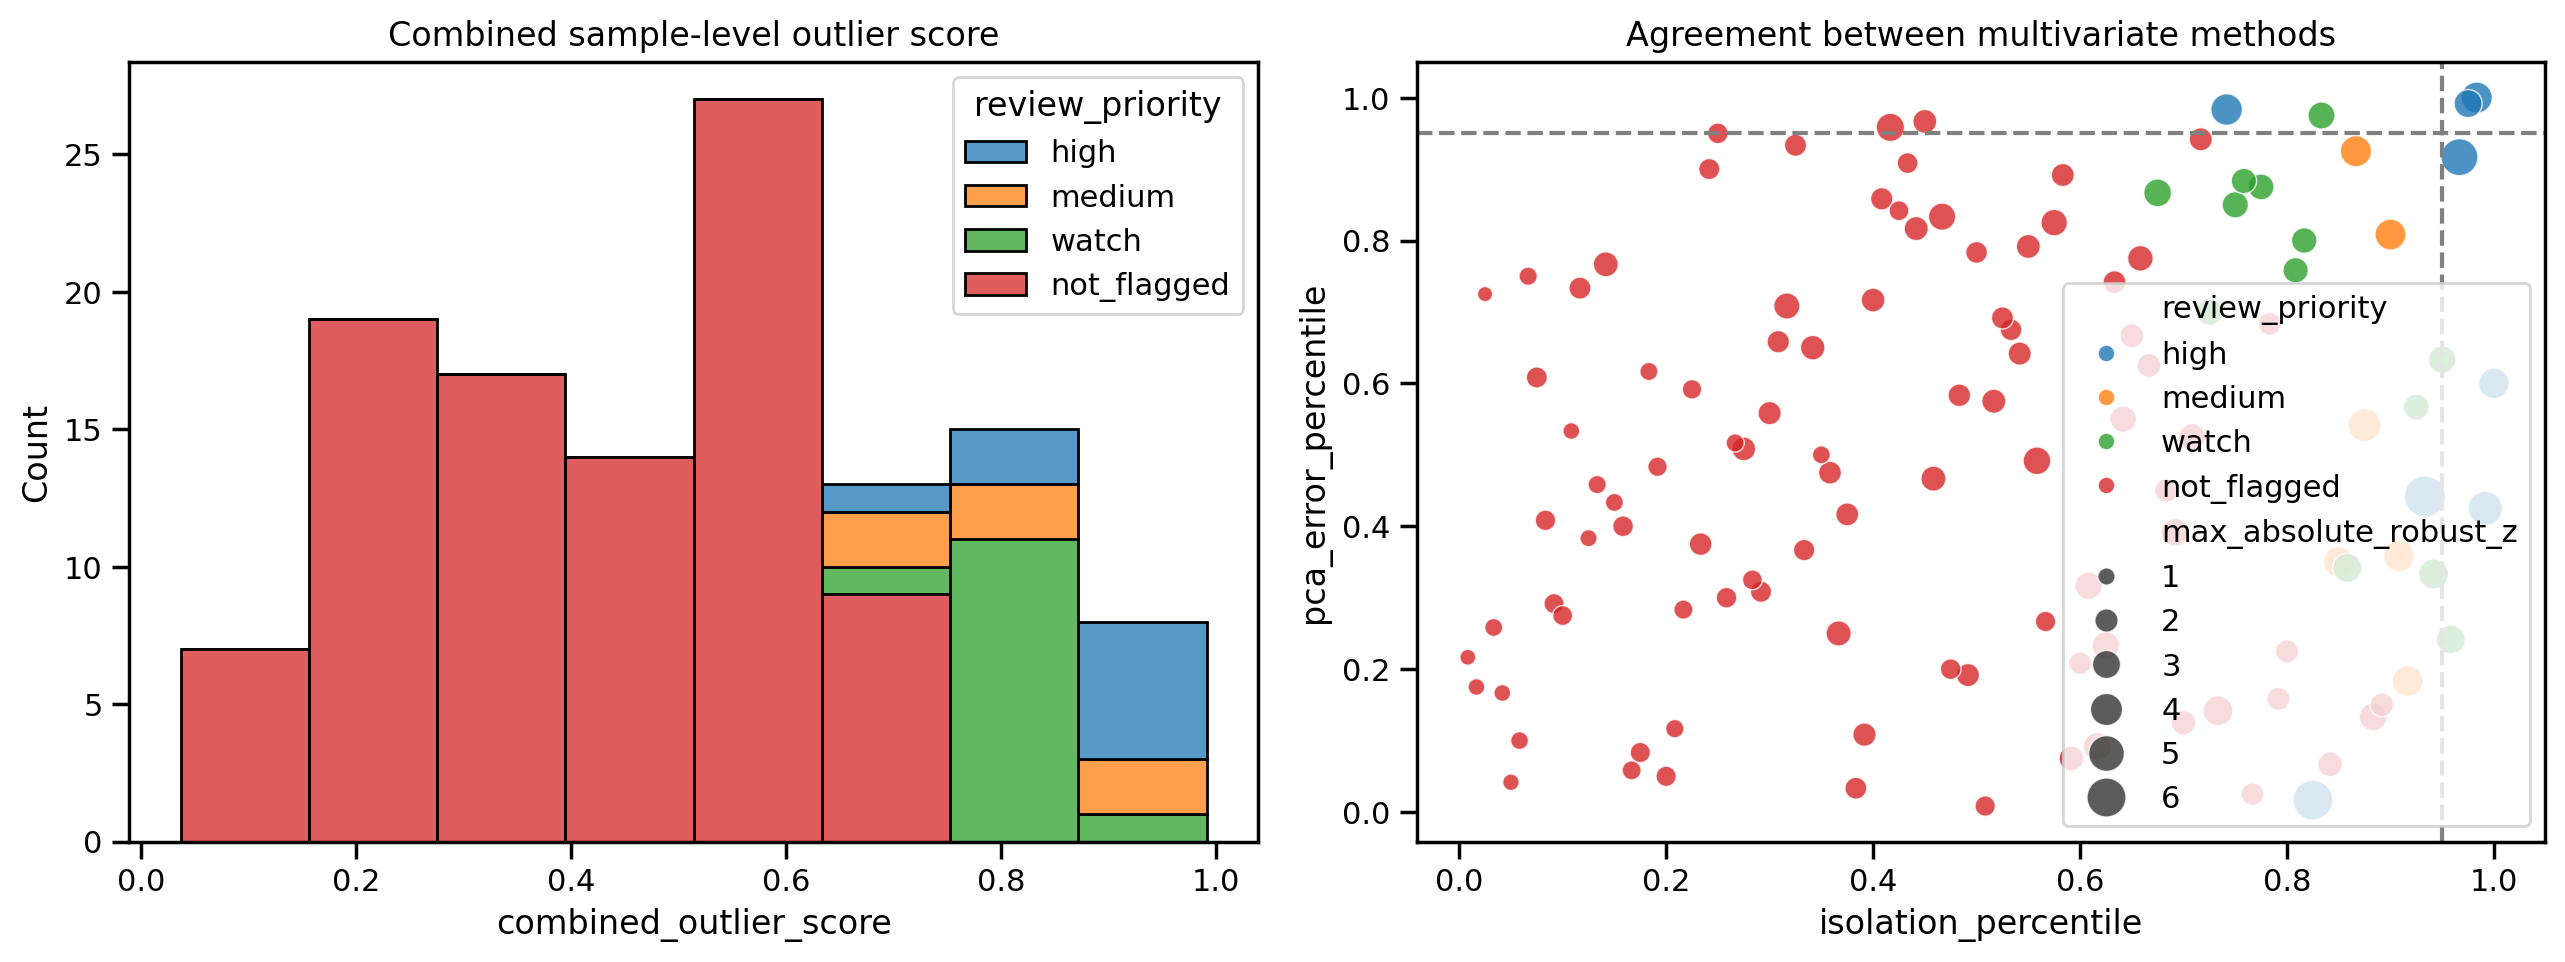

In [59]:
# Combined score and method agreement
plot_data = sample_outlier_report.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data=plot_data,
    x="combined_outlier_score",
    hue="review_priority",
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Combined sample-level outlier score")

sns.scatterplot(
    data=plot_data,
    x="isolation_percentile",
    y="pca_error_percentile",
    size="max_absolute_robust_z",
    hue="review_priority",
    sizes=(30, 220),
    alpha=0.8,
    ax=axes[1],
)
axes[1].axvline(MULTIVARIATE_ALERT_PERCENTILE, color="grey", linestyle="--")
axes[1].axhline(MULTIVARIATE_ALERT_PERCENTILE, color="grey", linestyle="--")
axes[1].set_title("Agreement between multivariate methods")

plt.tight_layout()
plt.show()

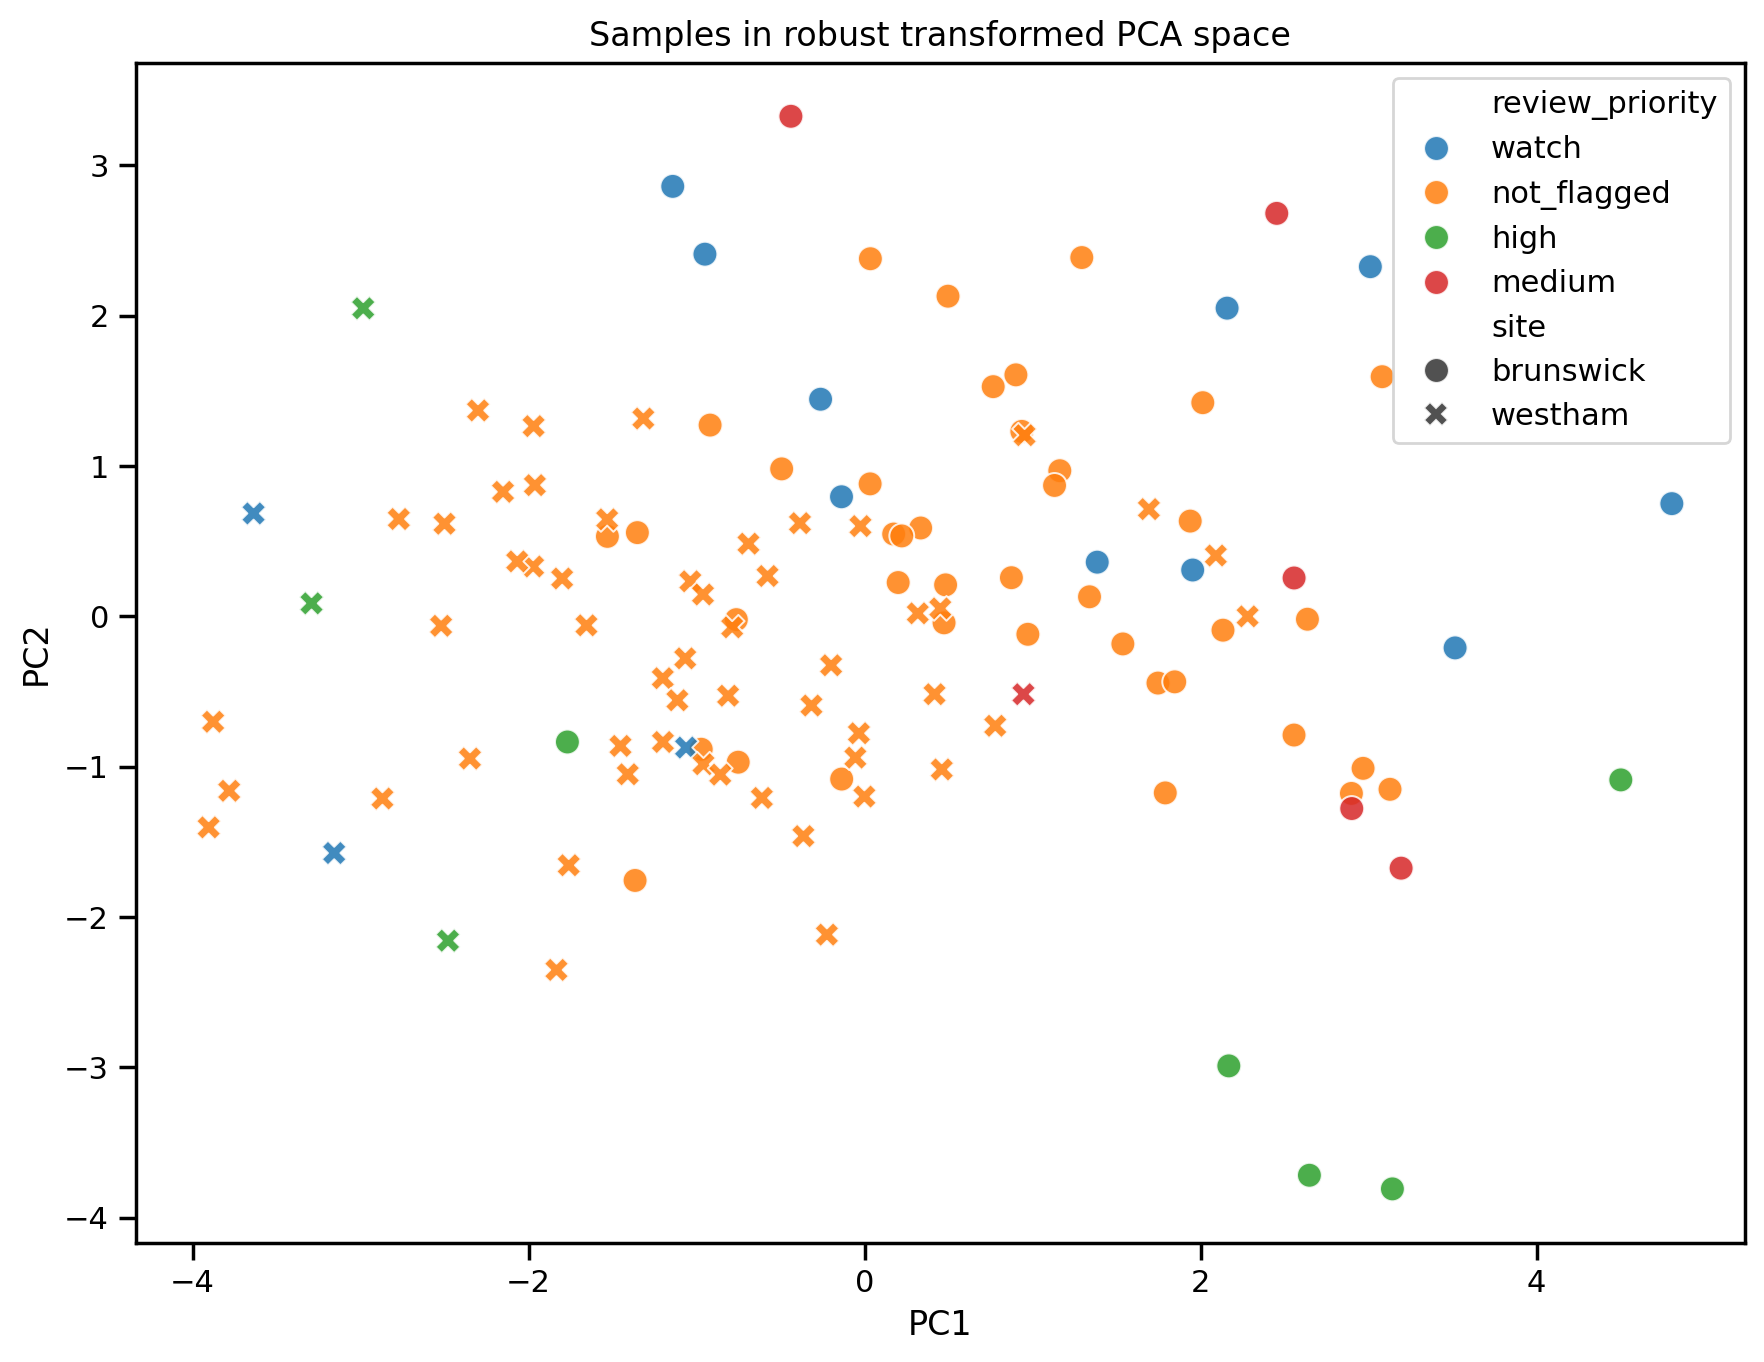

In [60]:
# First two PCA dimensions, if available.
if multivariate_result.pca_scores.shape[1] >= 2:
    pca_plot = (
        multivariate_result.pca_scores[["PC1", "PC2"]]
        .join(sample_outlier_report[["review_priority"]])
        .reset_index()
    )

    plt.figure(figsize=(9, 7))
    sns.scatterplot(
        data=pca_plot,
        x="PC1",
        y="PC2",
        hue="review_priority",
        style="site" if "site" in pca_plot.columns else None,
        s=80,
        alpha=0.85,
    )
    plt.title("Samples in robust transformed PCA space")
    plt.tight_layout()
    plt.show()

,n_low_outliers,n_high_outliers,total_outliers
variable,,,
Chl_allo2 (mg/m2),1,3,4
Percent Sand (%),2,0,2
Chla (mg/m2),0,2,2
DVCh-a (mg/m2),2,0,2
Proteins (mg/m2),0,2,2
Sample Total Dry Mass (g),0,1,1
Chl_allo1 (mg/m2),1,0,1
Moisture (%),0,0,0
Total SFA (mg/m2),0,0,0


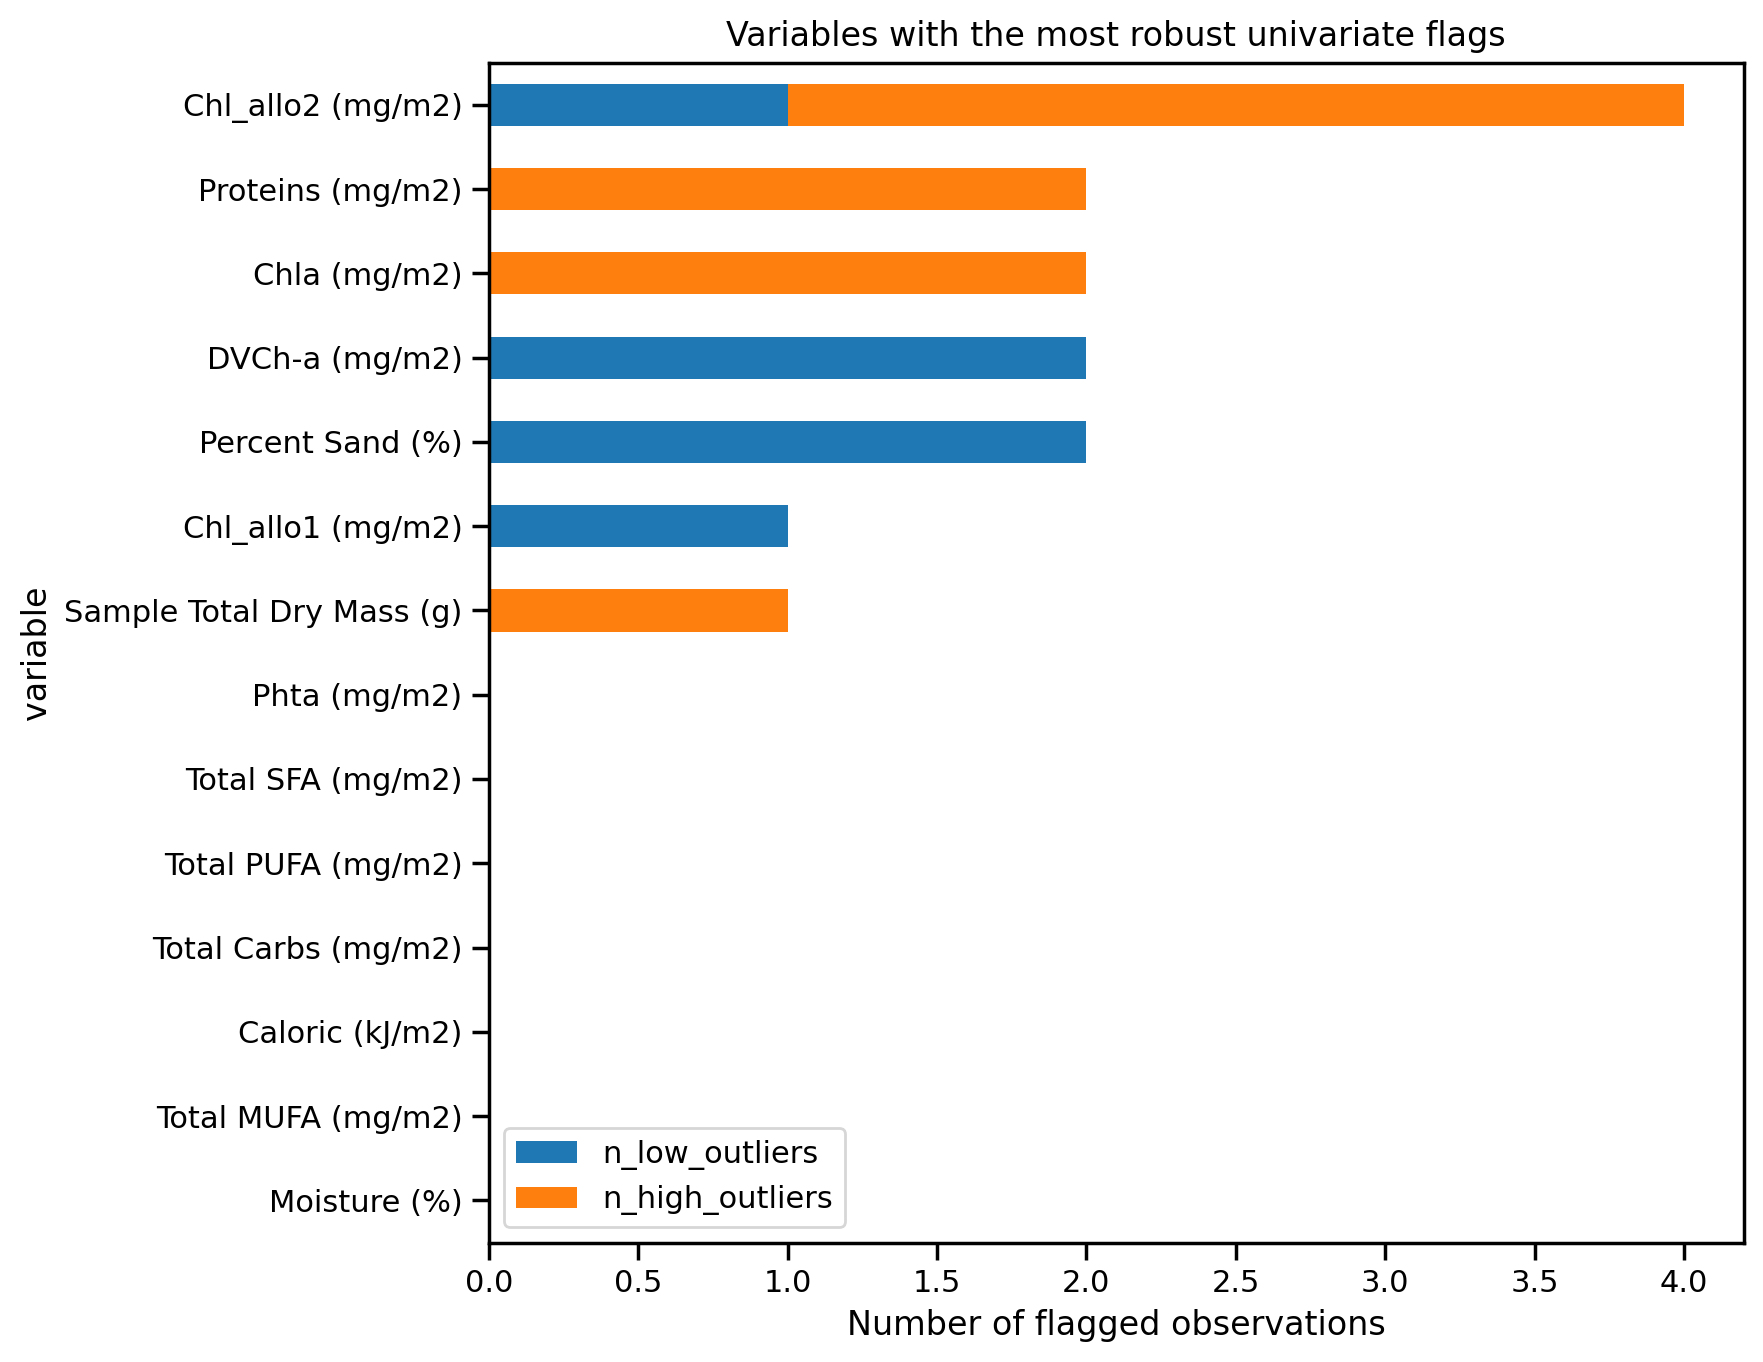

In [61]:
# Variables producing the most cell-level statistical flags.
variable_flag_counts = (
    univariate_result.variable_summary[
        ["n_low_outliers", "n_high_outliers"]
    ]
    .assign(total_outliers=lambda x: x.sum(axis=1))
    .sort_values("total_outliers", ascending=False)
)

display(variable_flag_counts.head(30))

top_variables = variable_flag_counts.head(20).sort_values("total_outliers")

plt.figure(figsize=(9, 7))
top_variables[["n_low_outliers", "n_high_outliers"]].plot.barh(
    stacked=True,
    ax=plt.gca(),
)
plt.title("Variables with the most robust univariate flags")
plt.xlabel("Number of flagged observations")
plt.tight_layout()
plt.show()

# Export review tables

In [62]:
def export_indexed_csv(df, path):
    if df is not None and not df.empty:
        df.to_csv(path)


export_indexed_csv(
    univariate_result.variable_summary,
    path_output_dir / "outlier_variable_summary.csv",
)
export_indexed_csv(
    univariate_result.cell_report,
    path_output_dir / "outlier_cell_level_candidates.csv",
)
export_indexed_csv(
    sample_outlier_report,
    path_output_dir / "outlier_sample_level_ranking.csv",
)
export_indexed_csv(
    retest_queue,
    path_output_dir / "outlier_retest_queue.csv",
)
export_indexed_csv(
    watch_list,
    path_output_dir / "outlier_watch_list.csv",
)
export_indexed_csv(
    representative_samples,
    path_output_dir / "representative_samples_global.csv",
)
export_indexed_csv(
    site_representative_samples,
    path_output_dir / "representative_samples_by_site.csv",
)

excel_path = path_output_dir / "candidate_outliers_and_representatives.xlsx"

with pd.ExcelWriter(excel_path) as writer:
    univariate_result.variable_summary.to_excel(
        writer, sheet_name="variable_summary"
    )
    univariate_result.cell_report.to_excel(
        writer, sheet_name="cell_candidates"
    )
    sample_outlier_report.to_excel(
        writer, sheet_name="sample_ranking"
    )
    retest_queue.to_excel(
        writer, sheet_name="retest_queue"
    )
    watch_list.to_excel(
        writer, sheet_name="watch_list"
    )
    representative_samples.to_excel(
        writer, sheet_name="representatives_global"
    )
    if not site_representative_samples.empty:
        site_representative_samples.to_excel(
            writer, sheet_name="representatives_site"
        )

print("Outputs written to:", path_output_dir.resolve())
print("Excel workbook:", excel_path)

Outputs written to: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/notebooks/analysis/outputs/lab_data
Excel workbook: outputs/lab_data/candidate_outliers_and_representatives.xlsx


# Suggested interpretation

## Retesting

Start with `retest_queue`, especially samples where:

- `n_methods_alerting >= 2`;
- several variables have large robust z-scores;
- Isolation Forest and PCA both rank the sample highly;
- the unusual result is scientifically implausible or conflicts with related measurements.

Do **not** automatically discard a result because it appears in the queue. Check extraction notes, dilution factors, chromatograms, transcription, sample mass, moisture correction, and whether the sample is a plausible environmental extreme.

## Representative samples

- `robust_center`: safest general “typical” sample.
- `closest_to_mean_profile`: closest actual observation to the overall multivariate mean.
- `lower_quartile_profile`: realistic lower-distribution case.
- `upper_quartile_profile`: realistic upper-distribution case.

The site-specific representatives are preferable when the impact and control areas should not be pooled.

## Future changes

The most useful parameters to revisit are:

- `columns_to_test_outliers`;
- `ROBUST_Z_THRESHOLD`;
- `MULTIVARIATE_ALERT_PERCENTILE`;
- `REPRESENTATIVE_MAX_OUTLIER_PERCENTILE`;
- whether the main analysis should be run separately by `site`, `round`, or another grouping.